# Matplotlib Exercises 3: 2D and 3D Plots

Run each provided-data cell, try the plotting task, and then compare your work with the answer below it.

You will practice astronomical images, overlaid contours, colorbars, 3D trajectories, and surfaces.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# if you want to drag the figure, install ipympl and use it by uncommenting the next line
# %matplotlib ipympl

rng = np.random.default_rng(42)

## Exercise 1 — Inspect a synthetic CCD exposure

Display the provided CCD image with `imshow` using a grayscale colormap and the origin at the lower-left. Limit the displayed range to 90–350 counts, label the detector coordinates, and add a colorbar.

In [ ]:
# Provided data — no knowledge of this image simulation is required.
yy, xx = np.indices((80, 100))
ccd = rng.normal(100, 3, (80, 100))
for star_x, star_y, peak in [(20, 30, 400), (75, 45, 650), (50, 65, 500), (85, 15, 300)]:
    ccd += peak * np.exp(-((xx - star_x) ** 2 + (yy - star_y) ** 2) / (2 * 2**2))
ccd[[8, 38, 72], [62, 12, 91]] = 900

### Answer

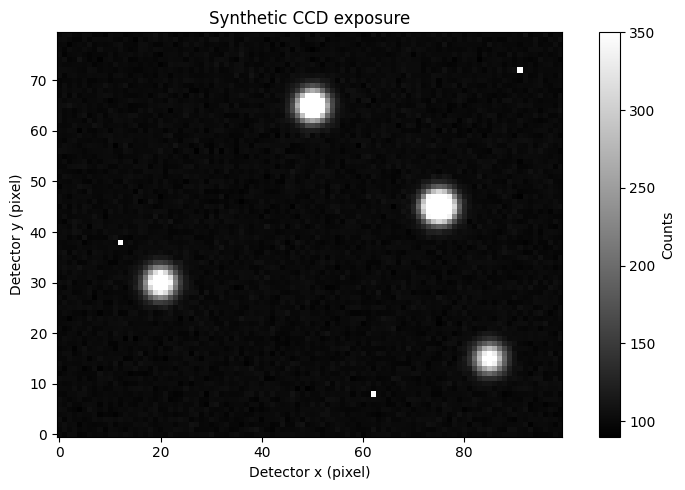

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(ccd, origin="lower", cmap="gray", vmin=90, vmax=350)
ax.set(xlabel="Detector x (pixel)", ylabel="Detector y (pixel)", title="Synthetic CCD exposure")
fig.colorbar(image, ax=ax, label="Counts")
fig.tight_layout()
plt.show()

## Exercise 2 — Combine filled terrain and contour lines

Draw filled elevation contours from the provided terrain and overlay thin black contour lines on the same Axes. Label alternating contour lines, add a colorbar, and use equal horizontal and vertical scales.

In [ ]:
# Provided data — the formulas only create an example terrain.
x = np.linspace(-4, 4, 160)
y = np.linspace(-3, 3, 120)
X, Y = np.meshgrid(x, y)
terrain = (
    2.8 * np.exp(-((X - 1.2) ** 2 + (Y + 0.4) ** 2) / 1.4)
    - 2.2 * np.exp(-((X + 1.5) ** 2 + (Y - 0.7) ** 2) / 0.9)
    + 0.15 * X
)
levels = np.linspace(terrain.min(), terrain.max(), 13)

### Answer

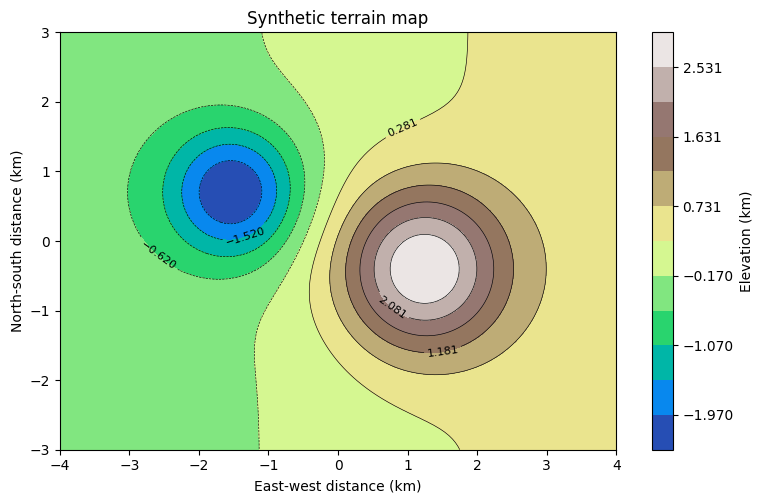

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
filled = ax.contourf(X, Y, terrain, levels=levels, cmap="terrain")
lines = ax.contour(X, Y, terrain, levels=levels, colors="black", linewidths=0.45)
ax.clabel(lines, levels=levels[::2], fontsize=8)  # Label every second line to reduce clutter.
ax.set(xlabel="East-west distance (km)", ylabel="North-south distance (km)", title="Synthetic terrain map", aspect="equal")
fig.colorbar(filled, ax=ax, label="Elevation (km)")
fig.tight_layout()
plt.show()

## Exercise 3 — Trace an inclined orbit in 3D

Plot the provided orbit as a 3D line rather than a cloud of points. Mark the central star with a large gold star and the starting position with a black circle. Add x, y, and z labels, a legend, and choose a viewing angle with `view_init`.

In [ ]:
# Provided data — coordinates along one inclined orbit.
theta = np.linspace(0, 2 * np.pi, 500)
orbit_x = 1.5 * np.cos(theta)
orbit_y = np.sin(theta)
orbit_z = 0.4 * np.sin(theta)

### Answer

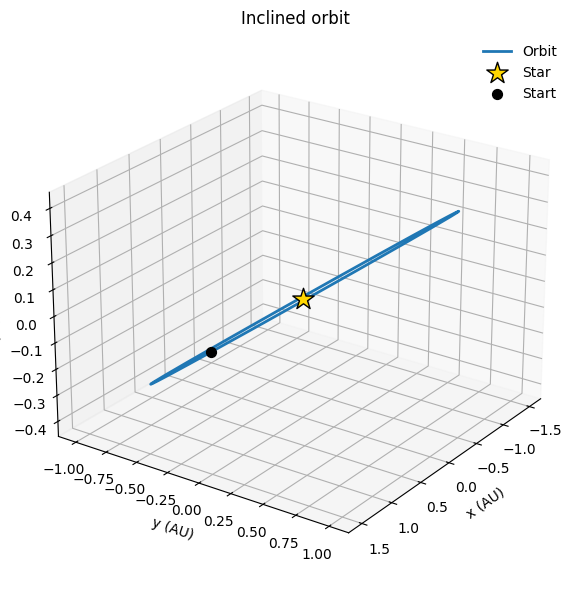

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": "3d"})
ax.plot(orbit_x, orbit_y, orbit_z, color="tab:blue", lw=2, label="Orbit")
ax.scatter(0, 0, 0, marker="*", s=260, color="gold", edgecolor="black", label="Star")
ax.scatter(orbit_x[0], orbit_y[0], orbit_z[0], s=50, color="black", label="Start")
ax.set(xlabel="x (AU)", ylabel="y (AU)", zlabel="z (AU)", title="Inclined orbit")
ax.view_init(elev=24, azim=35)  # Set a reproducible camera angle.
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Exercise 4 — Model a lunar crater surface

Plot the provided crater as a 3D surface with the `copper` colormap. Project contours below the lowest point and add a colorbar and axis labels.

In [ ]:
# Provided data — the formulas create a crater, raised rim, and gentle slope.
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
radius = np.hypot(X, Y)
crater = (
    -2.2 * np.exp(-(radius / 0.8) ** 2)
    + 0.8 * np.exp(-((radius - 1.25) / 0.18) ** 2)
    + 0.08 * X
)
floor = crater.min() - 0.5

### Answer

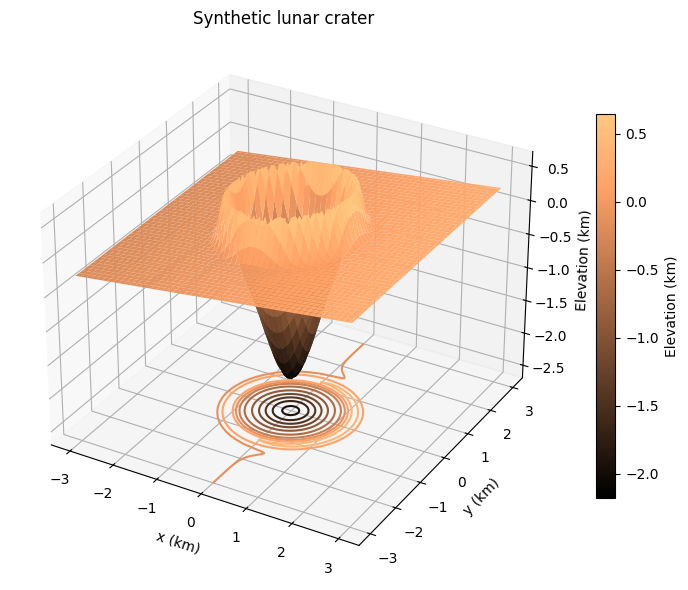

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": "3d"})
surface = ax.plot_surface(X, Y, crater, cmap="copper", linewidth=0)
ax.contour(
    X, Y, crater, zdir="z", offset=floor, levels=10, cmap="copper"
)  # Project the crater shape onto a plane below the surface.
ax.set(xlabel="x (km)", ylabel="y (km)", zlabel="Elevation (km)", zlim=(floor, crater.max()), title="Synthetic lunar crater")
fig.colorbar(surface, ax=ax, label="Elevation (km)", shrink=0.7)
fig.tight_layout()
plt.show()